# BMW Used Car Price Prediction (Regression)
โน้ตบุ๊กนี้ใช้สำหรับ train โมเดลประเมินราคารถมือสอง BMW แล้วบันทึกไฟล์ไปใช้ต่อใน Streamlit app


## 1.1 ติดตั้งและ import library


In [1]:
!pip install scikit-learn pandas numpy joblib --quiet

import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor


## 1.2 อัปโหลดและสำรวจข้อมูล


In [2]:
# กรณีใช้บน Google Colab
from google.colab import files
uploaded = files.upload()


Saving bmw.csv to bmw (1).csv


In [3]:
# เปลี่ยนชื่อไฟล์ตรงนี้ถ้าชื่อไม่ตรง
CSV_PATH = 'bmw.csv'
df = pd.read_csv("/content/bmw.csv")

print('Shape:', df.shape)
display(df.head())
print('Missing values:')
print(df.isna().sum())
print('Data types:')
print(df.dtypes)

Shape: (10781, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


Missing values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
Data types:
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object


# **ดูโครงสร้างข้อมูล**

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


- dataset มี X แถว Y คอลัมน์  
- ไม่มี/มี missing values  
- feature ส่วนใหญ่เป็น numerical และ categorical

# Missing Values

In [5]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


ไม่มี missing values

# Distribution

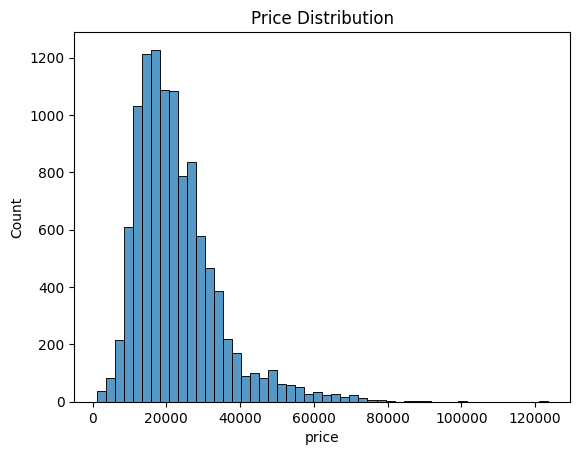

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.show()

- price มีลักษณะ skewed
- มี outliers ในช่วงราคาสูง

# ความสัมพันธ์

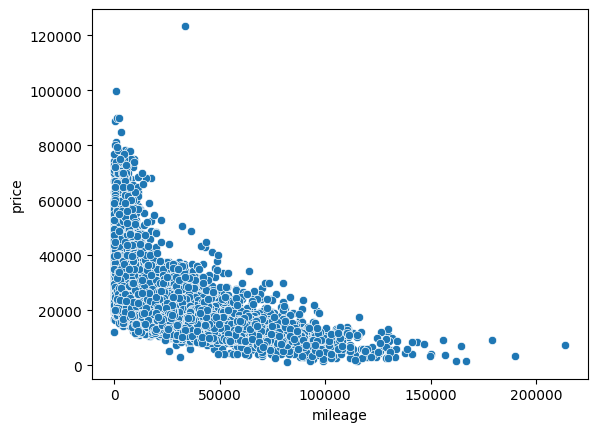

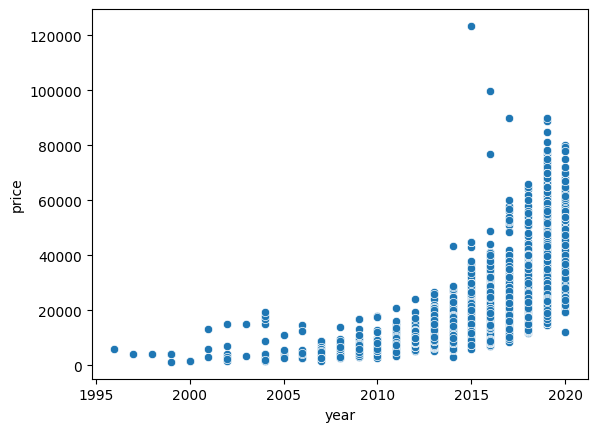

In [7]:
sns.scatterplot(x="mileage", y="price", data=df)
plt.show()

sns.scatterplot(x="year", y="price", data=df)
plt.show()

- mileage เพิ่ม → ราคา ลด
- year ใหม่ → ราคา สูง

# Categorical impact

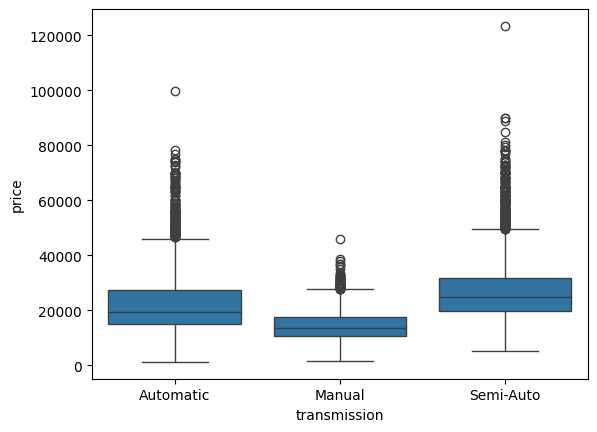

In [8]:
sns.boxplot(x="transmission", y="price", data=df)
plt.show()

# Correlation

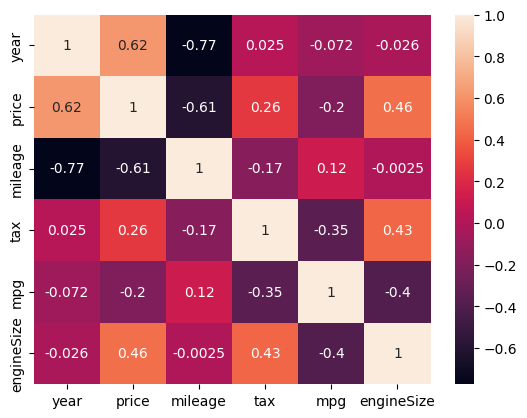

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## 1.3 เตรียม features และ target


In [ ]:
target = 'price'
X = df.drop(columns=[target])
y = df[target]

categorical_features = ['model', 'transmission', 'fuelType']
numerical_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

print('Categorical:', categorical_features)
print('Numerical:', numerical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)


Categorical: ['model', 'transmission', 'fuelType']
Numerical: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
Train size: (8624, 8)
Test size: (2157, 8)


## 1.4 สร้าง preprocessing pipeline


In [ ]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features),
    ('num', numerical_transformer, numerical_features)
])

preprocessor


ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['model', 'transmission', 'fuelType']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['year', 'mileage', 'tax', 'mpg',
                                  'engineSize'])])


- ใช้ OneHotEncoding เพราะ categorical ไม่มีลำดับ
- ใช้ SimpleImputer เพื่อจัดการ missing values
- ไม่ใช้ scaling เพราะ RandomForest ไม่ต้อง scale
- ใช้ Pipeline เพื่อป้องกัน data leakage และทำให้ workflow ถูกต้อง

## 1.5 ทดลองหลายอัลกอริทึม
เลือกเทียบหลายโมเดลก่อน แล้วค่อย tune โมเดลที่ดีที่สุด


In [ ]:
candidate_models = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

baseline_results = []

for name, regressor in candidate_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', regressor)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    baseline_results.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'R2': r2_score(y_test, pred)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values('MAE')
display(baseline_df)


,model,MAE,RMSE,R2
0,RandomForest,1607.930224,2720.009065,0.942787
1,ExtraTrees,1629.264386,2733.739482,0.942208
2,GradientBoosting,2064.784598,3299.258286,0.915825


## 1.6 Tune Hyperparameter ด้วย RandomizedSearchCV
ตัวอย่างนี้ tune RandomForest


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best params:", random_search.best_params_)
print("Best CV score (neg MAE):", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': None}
Best CV score (neg MAE): -1579.0658512692444


## 1.7 ประเมินผลบน Test Set


In [ ]:
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'Test MAE : {mae:,.2f}')
print(f'Test RMSE: {rmse:,.2f}')
print(f'Test R²  : {r2:.4f}')


Test MAE : 1,606.54
Test RMSE: 2,745.23
Test R²  : 0.9417


## 1.8 K-Fold Cross Validation
ช่วยให้การประเมินเสถียรกว่าการดูแค่ train/test split เดียว


In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae_scores = -cross_val_score(
    best_model, X_train, y_train,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_r2_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print('CV MAE scores:', cv_mae_scores)
print('CV MAE mean :', cv_mae_scores.mean())
print('CV MAE std  :', cv_mae_scores.std())
print('CV R² mean  :', cv_r2_scores.mean())


CV MAE scores: [1558.5173963  1543.59171505 1509.99208831 1496.88725404 1573.2394066 ]
CV MAE mean : 1536.4455720603698
CV MAE std  : 28.832850611068725
CV R² mean  : 0.9457567964959447


## 1.9 แปลผลเชิงธุรกิจ


In [ ]:
print('สรุปเชิงธุรกิจ')
print('- MAE คือความคลาดเคลื่อนเฉลี่ยของราคาที่ทำนาย')
print('- ถ้า MAE = 1,500 แปลว่าโดยเฉลี่ยโมเดลทายพลาดประมาณ £1,500 ต่อคัน')
print('- R² ยิ่งใกล้ 1 ยิ่งอธิบายความแปรปรวนของราคาได้ดี')
print('- สามารถนำโมเดลนี้ไปใช้ประเมินราคาเบื้องต้นในเว็บแอปก่อนประกาศขายหรือก่อนซื้อรถได้')


สรุปเชิงธุรกิจ
- MAE คือความคลาดเคลื่อนเฉลี่ยของราคาที่ทำนาย
- ถ้า MAE = 1,500 แปลว่าโดยเฉลี่ยโมเดลทายพลาดประมาณ £1,500 ต่อคัน
- R² ยิ่งใกล้ 1 ยิ่งอธิบายความแปรปรวนของราคาได้ดี
- สามารถนำโมเดลนี้ไปใช้ประเมินราคาเบื้องต้นในเว็บแอปก่อนประกาศขายหรือก่อนซื้อรถได้


## 1.10 บันทึกโมเดลไปใช้ใน Streamlit App


In [ ]:
os.makedirs('model_artifacts', exist_ok=True)

metadata = {
    'target': target,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'feature_order': categorical_features + numerical_features,
    'cv_mae_mean': float(cv_mae_scores.mean()),
    'cv_mae_std': float(cv_mae_scores.std()),
    'cv_r2_mean': float(cv_r2_scores.mean()),
    'best_params': random_search.best_params_,
    'choices': {
        'model': sorted(df['model'].dropna().unique().tolist()),
        'transmission': sorted(df['transmission'].dropna().unique().tolist()),
        'fuelType': sorted(df['fuelType'].dropna().unique().tolist())
    }
}

joblib.dump(best_model, 'model_artifacts/bmw_price_pipeline.pkl')
joblib.dump(metadata, 'model_artifacts/model_metadata.joblib')

with open('model_artifacts/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('บันทึกไฟล์สำเร็จในโฟลเดอร์ model_artifacts')

บันทึกไฟล์สำเร็จในโฟลเดอร์ model_artifacts


## 1.11 ดาวน์โหลดไฟล์กลับเครื่อง


In [ ]:
from google.colab import files
files.download('model_artifacts/bmw_price_pipeline.pkl')
files.download('model_artifacts/model_metadata.joblib')
files.download('model_artifacts/model_metadata.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>